# Natural Entity Recognition: Model Training and Model Prediction

(1) The first part of this notebook **fine-tunes the `bert-base-cased` model for NER** using the gold-standard annotated corpus (`data/annotations/final_annotation.csv`).

(2) The second part **executes inference** using the fine-tuned model across the full corpus sentences.

**Prerequisite:** `setup.ipynb` and `annotation.ipynb` must be previously executed.

In [1]:
import os
import csv
import sys
import random
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
import torch
from torch.nn import CrossEntropyLoss
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    Trainer,
    TrainingArguments,
    DataCollatorForTokenClassification,
    EarlyStoppingCallback,
)
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
from seqeval.metrics import classification_report, precision_score, recall_score, f1_score

import warnings
warnings.filterwarnings("ignore", message=".*pin_memory.*")

In [2]:
# setting the paths
NOTEBOOK_DIR = os.path.abspath(os.getcwd())

if os.path.basename(NOTEBOOK_DIR) == "notebooks":
    PROJECT_ROOT = os.path.dirname(NOTEBOOK_DIR)
else:
    PROJECT_ROOT = NOTEBOOK_DIR

FINAL_ANNOTATION_PATH = os.path.join(PROJECT_ROOT, "data", "annotations", "final_annotation.csv")
SENTENCE_SCORES_PATH = os.path.join(PROJECT_ROOT, "data", "annotations", "sentence_scores.csv")
FINAL_MODEL_DIR = os.path.join(PROJECT_ROOT, "checkpoints", "final", "saved_model")

EVAL_DIR = os.path.join(PROJECT_ROOT, "data", "model_evaluation")
os.makedirs(EVAL_DIR, exist_ok=True)
ERROR_TAXONOMY_PATH = os.path.join(EVAL_DIR, "error_taxonomy.csv")

INFERRED_DIR = os.path.join(PROJECT_ROOT, "data", "model_predictions")
os.makedirs(INFERRED_DIR, exist_ok=True)
OUTPUT_PATH = os.path.join(INFERRED_DIR, "inferred_entities.csv")

FIGURES_DIR = os.path.join(PROJECT_ROOT, "assets", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

# variables
ENTITY_TYPES = ["FLORA", "FAUNA", "WEATHER", "LANDSCAPE", "NATURE"]
N_FOLDS = 5
MAX_WEIGHT = 5.0  # cap extreme weights to avoid gradient instability
MIN_WEIGHT = 0.5   # prevent O from being so cheap that false positives become nearly free
RANDOM_SEED = 42
CONFIDENCE_THRESHOLD= 0.7

BERT_MODEL_NAME = "bert-base-cased"
CHECKPOINTS_DIR = os.path.join(PROJECT_ROOT, "checkpoints")

# add project root to sys.path to securely import custom scripts
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

from scripts.error_analysis import (
    extract_and_classify_fold,
    summarize_errors,
    export_error_samples,
    print_qualitative_analysis
)

label_list = ["O"] + [f"{p}-{t}" for t in ENTITY_TYPES for p in ("B", "I")]
label_to_id = {l: i for i, l in enumerate(label_list)}
id_to_label = {i: l for l, i in label_to_id.items()}

# 1. Model Training

## Data Loading

Gold-standard annotations are loaded and grouped by sentence.

To enforce complete **reproducibility**, `set_all_seeds()` fixes all sources of randomness.

In [7]:
def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    if torch.backends.mps.is_available():
        torch.backends.mps.deterministic = True
        torch.backends.mps.benchmark = False


set_all_seeds(RANDOM_SEED)  # baseline seed for anything before the fold loop

def load_sentences(path):
    with open(path, newline="", encoding="utf-8") as f:
        rows = list(csv.DictReader(f))

    sentences = {}
    order = []  # preserve first-seen order of sentence_ids

    for row in rows:
        s_id = row["sentence_id"]
        if s_id not in sentences:
            sentences[s_id] = {"sentence_id": s_id, "text": row["sentence_text"], "entities": []}
            order.append(s_id)

        span = row["target_span"].strip()
        if not span:
            continue  # this row represents "no entity"

        start, end = row["start_char"].strip(), row["end_char"].strip()
        if not start or not end:
            print(f"  WARNING: {s_id} has target_span {span!r} but missing "
                  f"start_char/end_char -- skipped.")
            continue

        sentences[s_id]["entities"].append({
            "start": int(start), "end": int(end),
            "label": row["entity_type"].strip(), "span": span,
        })

    for s_id in sentences:
        sentences[s_id]["entities"].sort(key=lambda e: e["start"])

    return [sentences[s_id] for s_id in order]


sentences = load_sentences(FINAL_ANNOTATION_PATH)

n_with_entities = sum(1 for s in sentences if s["entities"])
n_total_entities = sum(len(s["entities"]) for s in sentences)

print(f"Loaded {len(sentences)} sentences\n"
      f"  {n_with_entities} contain at least one entity\n"
      f"  {len(sentences) - n_with_entities} contain no entities (negative examples)\n"
      f"  {n_total_entities} entity mentions total")

Loaded 305 sentences
  238 contain at least one entity
  67 contain no entities (negative examples)
  795 entity mentions total


## Tokenization and Subword Alignment

The tokenizer and the 11-label BIO (Beginning, Inside, Outside) tagging scheme are initialized here. 

The `tokenize_and_align_labels()` function maps character offsets to subword tokens under the following constraints:
*   Only the **first** subword of a complete word receives a valid `B-` or `I-` label.
*   Continuation subwords and special tokens are assigned a label of `-100`.

This approach aligns evaluation metrics with whole words and ensures the PyTorch loss function ignores subword fragments during optimization.

In [6]:
tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)

label_list = ["O"] + [f"{p}-{t}" for t in ENTITY_TYPES for p in ("B", "I")]
label_to_id = {l: i for i, l in enumerate(label_list)}
id_to_label = {i: l for l, i in label_to_id.items()}

print(f"{len(label_list)} labels:", label_list)


def tokenize_and_align_labels(sentence, tokenizer, label_to_id):
    encoding = tokenizer(sentence["text"], return_offsets_mapping=True, truncation=True)
    offsets = encoding["offset_mapping"]
    word_ids = encoding.word_ids()

    labels = []
    previous_word_id = None
    started_entities = set()  # indices into sentence["entities"] already given a B- tag

    for token_idx, (start, end) in enumerate(offsets):
        word_id = word_ids[token_idx]

        if word_id is None or word_id == previous_word_id:
            labels.append(-100)  # special token or a continuation subword
        else:
            matched_idx = None
            for i, ent in enumerate(sentence["entities"]):
                if start >= ent["start"] and end <= ent["end"]:
                    matched_idx = i
                    break

            if matched_idx is None:
                labels.append(label_to_id["O"])
            elif matched_idx not in started_entities:
                labels.append(label_to_id[f"B-{sentence['entities'][matched_idx]['label']}"])
                started_entities.add(matched_idx)
            else:
                labels.append(label_to_id[f"I-{sentence['entities'][matched_idx]['label']}"])

        previous_word_id = word_id

    return {"input_ids": encoding["input_ids"],
            "attention_mask": encoding["attention_mask"],
            "labels": labels}

11 labels: ['O', 'B-FLORA', 'I-FLORA', 'B-FAUNA', 'I-FAUNA', 'B-WEATHER', 'I-WEATHER', 'B-LANDSCAPE', 'I-LANDSCAPE', 'B-NATURE', 'I-NATURE']


## Verify Tokenization

Verify that subword alignments map correctly back to original entity spans.

In [8]:
def decode_bio_to_spans(offsets, word_ids, labels, id_to_label):
    spans, current, current_word_id = [], None, None
    previous_word_id = None
    for (start, end), wid, lab_id in zip(offsets, word_ids, labels):
        if wid is None:
            previous_word_id = wid
            continue
        if wid == previous_word_id:
            # continuation subword - ignore whatever label sits here,
            # regardless of value; only a word's FIRST subword counts
            if current is not None and wid == current_word_id:
                current["end"] = end
            previous_word_id = wid
            continue
        if lab_id != -100:
            lab = id_to_label[lab_id]
            if lab == "O":
                if current: spans.append(current); current = None
            elif lab.startswith("B-"):
                if current: spans.append(current)
                current = {"start": start, "end": end, "label": lab[2:]}
                current_word_id = wid
            elif lab.startswith("I-"):
                if current and current["label"] == lab[2:]:
                    current["end"] = end; current_word_id = wid
                else:
                    if current: spans.append(current)
                    current = {"start": start, "end": end, "label": lab[2:]}
                    current_word_id = wid
        previous_word_id = wid
    if current: spans.append(current)
    return spans


mismatches = 0
for s in sentences:
    encoding = tokenizer(s["text"], return_offsets_mapping=True, truncation=True)
    result = tokenize_and_align_labels(s, tokenizer, label_to_id)
    decoded = decode_bio_to_spans(encoding["offset_mapping"], encoding.word_ids(), result["labels"], id_to_label)

    original = sorted((e["start"], e["end"], e["label"]) for e in s["entities"])
    decoded_sorted = sorted((d["start"], d["end"], d["label"]) for d in decoded)

    if original != decoded_sorted:
        mismatches += 1
        print(f"MISMATCH in {s['sentence_id']}: {s['text']}")
        print("  original:", original, "\n  decoded: ", decoded_sorted)

print(f"\nChecked {len(sentences)} sentences - {mismatches} mismatches found.")
assert mismatches == 0, (
    f"{mismatches} sentences failed the verification - fix final_annotation.csv"
)


Checked 305 sentences - 0 mismatches found.


## Stratified K-Fold Split

The dataset is partitioned into `N_FOLDS` folds using `MultilabelStratifiedKFold`. Given the sparsity of certain classes (e.g., `NATURE` contains approximately 33 total mentions), random splitting risks isolating rare entities into a single fold. Stratification ensures a uniform distribution of all entity types across every fold.

*The output below verifies the token-level entity distribution per fold.*

In [9]:
# multi-label indicator: for each sentence, return which entity types contain at least one mention
Y = np.zeros((len(sentences), len(ENTITY_TYPES)), dtype=int)
for i, s in enumerate(sentences):
    types_present = {e["label"] for e in s["entities"]}
    for j, t in enumerate(ENTITY_TYPES):
        if t in types_present:
            Y[i, j] = 1

X = np.arange(len(sentences)).reshape(-1, 1)

mskf = MultilabelStratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)
for fold_idx, (_, val_idx) in enumerate(mskf.split(X, Y)):
    for i in val_idx:
        sentences[i]["fold"] = fold_idx

fold_counts = [Counter() for _ in range(N_FOLDS)]
for s in sentences:
    for e in s["entities"]:
        fold_counts[s["fold"]][e["label"]] += 1

print(f"{'':12s}" + "".join(f"fold{f:<8d}" for f in range(N_FOLDS)))
for t in ENTITY_TYPES:
    print(f"{t:12s}" + "".join(f"{fold_counts[f][t]:<12d}" for f in range(N_FOLDS)))

            fold0       fold1       fold2       fold3       fold4       
FLORA       15          16          16          14          16          
FAUNA       11          9           11          10          14          
WEATHER     50          66          61          60          74          
LANDSCAPE   51          78          60          55          75          
NATURE      6           6           6           8           7           


## Class-Weighted Loss

The dataset is heavily skewed: approximately 95% of all tokens belong to the `"O"` (background) class, while the rarest class (`FAUNA`) represents less than 0.5%. Under an unweighted loss function, the model could disproportionately ignore rare classes while maintaining high overall accuracy.

A balanced inverse-frequency weighting scheme (`total / (n_classes * count)`) is computed via `compute_class_weights()` to penalize misclassifications on rare entities more heavily. A ceiling limit (`MAX_WEIGHT`) prevents early training instability caused by extreme weights.

In [10]:
def compute_class_weights(sentences, tokenizer, label_to_id):
    counts = Counter()
    for s in sentences:
        result = tokenize_and_align_labels(s, tokenizer, label_to_id)
        for lab_id in result["labels"]:
            if lab_id != -100:
                counts[lab_id] += 1

    total = sum(counts.values())
    n_classes = len(label_to_id)
    weights = torch.ones(n_classes)
    for label_id, count in counts.items():
        weights[label_id] = total / (n_classes * count)
    return weights


class_weights = compute_class_weights(sentences, tokenizer, label_to_id)
class_weights_capped = torch.clamp(class_weights, min=MIN_WEIGHT, max=MAX_WEIGHT)

print(f"{'label':12s} {'raw':>8s} {'capped':>8s}")
for i, (raw, capped) in enumerate(zip(class_weights, class_weights_capped)):
    print(f"{id_to_label[i]:12s} {raw:>8.2f} {capped:>8.2f}")

label             raw   capped
O                0.10     0.50
B-FLORA         14.01     5.00
I-FLORA         83.01     5.00
B-FAUNA         19.62     5.00
I-FAUNA        134.89     5.00
B-WEATHER        3.47     3.47
I-WEATHER       43.16     5.00
B-LANDSCAPE      3.38     3.38
I-LANDSCAPE     25.10     5.00
B-NATURE        32.70     5.00
I-NATURE        49.05     5.00


## Custom Weighted-Loss Trainer

The default Hugging Face `Trainer` computes unweighted `CrossEntropyLoss`. The `Trainer` class is overridden via custom subclassing to integrate computed class weights into the loss function.

`ignore_index=-100` ensures special tokens and subword continuations do not contribute to loss gradients.

In [11]:
class WeightedLossTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        loss_function = CrossEntropyLoss(
            weight=self.class_weights.to(logits.device),
            ignore_index=-100,
        )
        loss = loss_function(logits.view(-1, model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

## Dataset Construction

`build_dataset()` formats tokenized records into standard Hugging Face `datasets.Dataset` objects.

`DataCollatorForTokenClassification` dynamically pads sequences within each batch. Labels are padded with `-100` rather than `0` to prevent the model from treating padding positions as valid background (`"O"`) entities.

In [12]:
def build_dataset(sentence_list, tokenizer, label_to_id):
    records = [tokenize_and_align_labels(s, tokenizer, label_to_id) for s in sentence_list]
    return Dataset.from_list(records)


data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer, label_pad_token_id=-100)

## Evaluation helper

Generate sequence evaluation metrics (Precision, Recall, F1) using `seqeval` on held-out fold data.

In [13]:
def evaluate_fold(trainer, eval_dataset, id_to_label):
    predictions, labels, _ = trainer.predict(eval_dataset)
    predictions = np.argmax(predictions, axis=2)

    true_labels = [[id_to_label[l] for l in label if l != -100] for label in labels]
    true_predictions = [
        [id_to_label[p] for p, l in zip(pred, label) if l != -100]
        for pred, label in zip(predictions, labels)
    ]

    report = classification_report(true_labels, true_predictions, output_dict=True, zero_division=0)
    overall = {
        "precision": precision_score(true_labels, true_predictions),
        "recall": recall_score(true_labels, true_predictions),
        "f1": f1_score(true_labels, true_predictions),
    }
    return overall, report, predictions, labels

## Train and Evaluate: full 5-fold loop

Execute the complete cross-validation pipeline: for each fold, a fresh model is instantiated, trained on the remaining four folds, and evaluated against the held-out validation set.

An `EarlyStoppingCallback(patience=2)` halts training when validation loss ceases to improve, preventing overfitting.

In [ ]:
all_fold_reports = []
all_fold_overall = []
all_fold_errors = []

for fold in range(N_FOLDS):

    print(f"\n{'='*20} FOLD {fold} {'='*20}")

    set_all_seeds(RANDOM_SEED + fold)
    train_sents = [s for s in sentences if s["fold"] != fold]
    val_sents = [s for s in sentences if s["fold"] == fold]
    ds_train_fold = build_dataset(train_sents, tokenizer, label_to_id)
    ds_val_fold = build_dataset(val_sents, tokenizer, label_to_id)

    model_fold = AutoModelForTokenClassification.from_pretrained(
        BERT_MODEL_NAME,
        num_labels=len(label_list),
        id2label=id_to_label,
        label2id=label_to_id,
    )

    training_args_fold = TrainingArguments(
        output_dir=os.path.join(CHECKPOINTS_DIR, f"fold{fold}"),
        num_train_epochs=6,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        learning_rate=2e-5,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",           # must match eval_strategy for load_best_model_at_end
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        save_total_limit=1,              # only keep the best checkpoint, not every epoch
        logging_steps=10,
        report_to="none",
    )

    trainer_fold = WeightedLossTrainer(
        model=model_fold,
        args=training_args_fold,
        train_dataset=ds_train_fold,
        eval_dataset=ds_val_fold,
        data_collator=data_collator,
        class_weights=class_weights_capped,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )

    trainer_fold.train()
    overall, report, predictions, labels = evaluate_fold(trainer_fold, ds_val_fold, id_to_label)


    print(
            f"Fold {fold} overall -> Precision: {overall['precision']:.3f} | "
            f"Recall: {overall['recall']:.3f} | F1: {overall['f1']:.3f}"
        )
    
    all_fold_overall.append(overall)
    all_fold_reports.append(report)

    
    fold_errors = extract_and_classify_fold(
        val_sentences=val_sents,
        predictions=predictions,
        labels=labels,
        tokenizer=tokenizer,
        id_to_label=id_to_label,
        decode_fn=decode_bio_to_spans
    )
    all_fold_errors.append(fold_errors)

# average across all 5 folds -> the final reported number
print(f"\n{'='*20} AVERAGED ACROSS {N_FOLDS} FOLDS {'='*20}")

avg = {m: np.mean([f[m] for f in all_fold_overall]) for m in ["precision", "recall", "f1"]}
print(f"Overall Across Folds -> Precision: {avg['precision']:.2f} | Recall: {avg['recall']:.2f} | F1: {avg['f1']:.2f}")

per_class_avg = {}
for ent in ENTITY_TYPES:
    p, r, f1 = np.mean([[s[ent]["precision"], s[ent]["recall"], s[ent]["f1-score"]]
                        for s in all_fold_reports if ent in s], axis=0)
    per_class_avg[ent] = {"precision": p, "recall": r, "f1": f1}
    print(f"{ent:12s} precision={p:.2f}  recall={r:.2f}  f1={f1:.2f}")


==================== FOLD 0 ====================


Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss
1,1.054000,0.633439
2,0.516100,0.335395
3,0.381900,0.247845
4,0.255900,0.230831
5,0.199900,0.218777
6,0.149800,0.227032


Fold 0 overall -> Precision: 0.745 | Recall: 0.880 | F1: 0.807

==================== FOLD 1 ====================


Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Epoch,Training Loss,Validation Loss
1,0.921100,0.827188
2,0.400700,0.586781
3,0.433700,0.530809
4,0.181900,0.506122
5,0.166600,0.557274
6,0.118500,0.530551


Fold 3 overall -> Precision: 0.647 | Recall: 0.810 | F1: 0.719

==================== FOLD 4 ====================


Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss
1,0.957300,0.652321
2,0.610300,0.380377
3,0.288900,0.313672
4,0.229200,0.289562
5,0.189300,0.268631
6,0.191500,0.273639


Fold 4 overall -> Precision: 0.668 | Recall: 0.876 | F1: 0.758

==================== AVERAGED ACROSS 5 FOLDS ====================
Overall Across Folds -> Precision: 0.68 | Recall: 0.85 | F1: 0.76
FLORA        precision=0.72  recall=0.82  f1=0.76
FAUNA        precision=0.71  recall=0.81  f1=0.75
WEATHER      precision=0.72  recall=0.89  f1=0.80
LANDSCAPE    precision=0.65  recall=0.86  f1=0.74
NATURE       precision=0.72  recall=0.51  f1=0.58


## Visualizing Performance x Category

Performance does not simply track class abundance - FLORA (rarer class) outperforms the more abundant LANDSCAPE, and FAUNA (smallest class) substantially outperforms NATURE despite having fewer tokens. NATURE is the clear outlier: its precision is comparable to every other category, but its recall (~0.51) is far lower than any of them, indicating the model is being conservative rather than confused on this class - consistent with NATURE being the most semantically ambiguous category in the schema (see annotation guideline), not simply the rarest.

Wrote scores_x_category.csv
Wrote scores_x_category.png


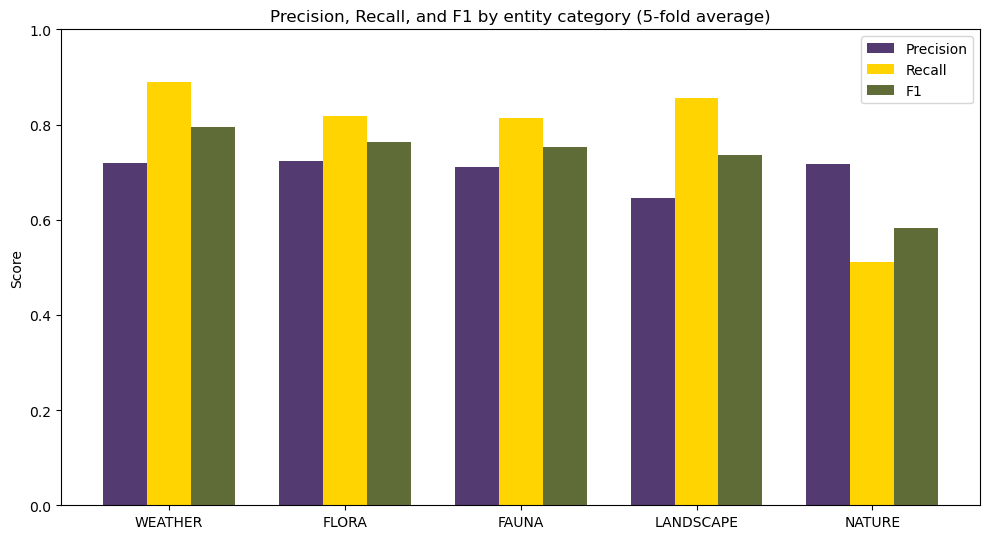

In [15]:
category_results_path = os.path.join(EVAL_DIR, "scores_x_category.csv")

with open(category_results_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["entity_type", "precision", "recall", "f1"])
    for ent, m in per_class_avg.items():
        writer.writerow([ent, round(m["precision"], 3), round(m["recall"], 3), round(m["f1"], 3)])
print(f"Wrote scores_x_category.csv")

types = sorted(per_class_avg, key=lambda t: -per_class_avg[t]["f1"])
precision_vals = [per_class_avg[t]["precision"] for t in types]
recall_vals = [per_class_avg[t]["recall"] for t in types]
f1_vals = [per_class_avg[t]["f1"] for t in types]

x = np.arange(len(types))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.bar(x - width, precision_vals, width, label="Precision", color="#533A71")
ax.bar(x,          recall_vals,    width, label="Recall", color="#FFD400")
ax.bar(x + width,  f1_vals,        width, label="F1", color="#606C38")
ax.set_ylabel("Score")
ax.set_title("Precision, Recall, and F1 by entity category (5-fold average)")
ax.set_xticks(x)
ax.set_xticklabels(types)
ax.set_ylim(0, 1)
ax.legend()
fig.tight_layout()

chart_path = os.path.join(FIGURES_DIR, "scores_x_category.png")
fig.savefig(chart_path, dpi=150)
print(f"Wrote scores_x_category.png")
plt.show()

## Error Taxonomy & Summary

Every prediction-to-gold-standard mismatch across all five folds is classified into one of four categories:
*   **Label Confusion:** Correct span boundaries, incorrect entity type.
*   **Boundary Error:** Correct entity type, incorrect span edges.
*   **Spurious:** Predicted entity where none exists (false positive).
*   **Missed:** Unpredicted true entity (false negative).

Results are aggregated and exported to `error_taxonomy.csv` for analysis.

In [17]:
df_summary = summarize_errors(all_fold_errors)
display(df_summary)

_ = export_error_samples(all_fold_errors, save_path=ERROR_TAXONOMY_PATH)
print(f"Full error dataset exported to error_taxonomy.csv")

qualitative_samples = print_qualitative_analysis(
    all_fold_errors,
    error_type="spurious",
    focus_classes={"FAUNA", "NATURE"},
    sample_size=5,
)

,Error Category,Total Count,Percentage
0,label_confusion,28,7.93
1,boundary_error,106,30.03
2,spurious,181,51.27
3,missed,38,10.76


Full error dataset exported to error_taxonomy.csv
--- QUALITATIVE ANALYSIS: SPURIOUS ---
[Fold 4 | ID: s00123] I said with men, and with the thoughts of men, 60 I held but slight communion; but instead, My joy was in the wilderness,--to breathe The difficult air of the iced mountain's top,Where the birds dare not build--nor insect's wing Flit o'er the herbless granite; or to plunge Into the torrent, and to roll along On the swift whirl of the new-breaking wave Of river-stream, or Ocean, in their flow.
   DETAILS: {'text': 'wing', 'pred_label': 'FAUNA'}

[Fold 0 | ID: s00076] Whose happy flight is highest into heaven, Well may'st thou swoop so near me--I should be Thy prey, and gorge thine eaglets; thou art gone Where the eye cannot follow thee; but thine Yet pierces downward, onward, or above, With a pervading vision.--Beautiful!
   DETAILS: {'text': 'prey', 'pred_label': 'FAUNA'}

[Fold 4 | ID: s00033] A populous solitude of bees and birds, And fairy-formed and many coloured things, W

## Confidence Thresholding

Error analysis reveales that a large amount of errors are spurious (false positives) caused by trusting low-confidence predictions. A post-processing confidence threshold forces any prediction below `CONFIDENCE_THRESHOLD` back to `"O"`.

**Threshold Selection**: swept from 0.0-0.9 across all 5 folds and evaluated by reloading saved checkpoints. The benefit of thresholding is robust across every fold; the exact peak is broad and fairly flat, so 0.7 is reported as an evidence-based, generalized choice.

In [18]:
def evaluate_with_threshold(trainer, eval_dataset, id_to_label, threshold=CONFIDENCE_THRESHOLD):
    raw_logits, labels, _ = trainer.predict(eval_dataset)
    probs = torch.nn.functional.softmax(torch.tensor(raw_logits), dim=-1).numpy()
    predictions = np.argmax(probs, axis=2)
    confidences = np.max(probs, axis=2)

    o_id = label_to_id["O"]
    predictions = np.where(confidences < threshold, o_id, predictions)

    true_labels = [[id_to_label[l] for l in label if l != -100] for label in labels]
    true_predictions = [
        [id_to_label[p] for p, l in zip(pred, label) if l != -100]
        for pred, label in zip(predictions, labels)
    ]
    return {
        "precision": precision_score(true_labels, true_predictions),
        "recall": recall_score(true_labels, true_predictions),
        "f1": f1_score(true_labels, true_predictions),
    }


def load_fold_trainer(fold_num, checkpoints_dir, tokenizer, data_collator):
    fold_dir = os.path.join(checkpoints_dir, f"fold{fold_num}")
    checkpoint_subdirs = [d for d in os.listdir(fold_dir) if d.startswith("checkpoint-")]
    checkpoint_path = os.path.join(fold_dir, sorted(checkpoint_subdirs)[-1])
    model_reloaded = AutoModelForTokenClassification.from_pretrained(checkpoint_path)
    predict_args = TrainingArguments(
        output_dir=os.path.join(CHECKPOINTS_DIR, "tmp_predict"),
        report_to="none",
        per_device_eval_batch_size=8,
    )
    return Trainer(model=model_reloaded, args=predict_args, data_collator=data_collator)


thresholded_results = []
for fold_num in range(N_FOLDS):
    trainer_reloaded = load_fold_trainer(fold_num, CHECKPOINTS_DIR, tokenizer, data_collator)
    val_sents_fold = [s for s in sentences if s["fold"] == fold_num]
    ds_val_reloaded = build_dataset(val_sents_fold, tokenizer, label_to_id)

    result = evaluate_with_threshold(trainer_reloaded, ds_val_reloaded, id_to_label)
    thresholded_results.append(result)

thresholded_f1s = [r["f1"] for r in thresholded_results]

print(f"{'Fold':6s} {'Precision':>10s} {'Recall':>10s} {'F1':>10s}")
print("-" * 38)
for fold, result in enumerate(thresholded_results):
    print(f"{fold:<6d} {result['precision']:>10.3f} {result['recall']:>10.3f} {result['f1']:>10.3f}")
print("-" * 38)
avg_p = np.mean([r["precision"] for r in thresholded_results])
avg_r = np.mean([r["recall"] for r in thresholded_results])
avg_f1 = np.mean([r["f1"] for r in thresholded_results])
print(f"{'Avg':<6s} {avg_p:>10.3f} {avg_r:>10.3f} {avg_f1:>10.3f}")

Fold    Precision     Recall         F1
--------------------------------------
0           0.824      0.812      0.818
1           0.762      0.749      0.755
2           0.842      0.799      0.820
3           0.752      0.741      0.747
4           0.816      0.833      0.824
--------------------------------------
Avg         0.799      0.787      0.793


## Visualizing the Threshold

Confidence thresholding is a post-processing step applied after training is fully complete - model logits are computed once per fold and cached, allowing different threshold values to be tested without re-running expensive forward passes.

- Fold-by-Fold Impact: comparing F1 before and after applying the threshold shows that the performance boost isn't just an overall average - every single fold improves, though the size of the gain varies: Folds 2 and 4 show a substantial jump, while Folds 0 and 1 improve only marginally.

- Threshold Sweep: sweeping across different confidence values reveals a broad and relatively stable optimum around 0.6–0.8 rather than a single sharply defined best value - 0.7 is identified as the best-supported point within that range, rather than as a precisely determined value.

Wrote threshold_comparison.csv
Wrote threshold_comparison.png


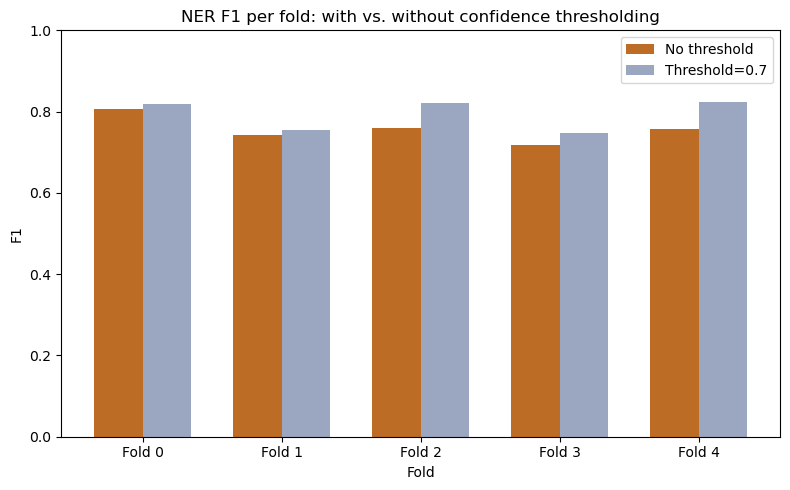

In [19]:
THRESHOLD_RESULTS_PATH = os.path.join(EVAL_DIR, "threshold_comparison.csv")

with open(THRESHOLD_RESULTS_PATH, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["fold", "f1_no_threshold", f"f1_threshold_{CONFIDENCE_THRESHOLD}", "delta"])
    for fold, (unthresh, thresh) in enumerate(zip(all_fold_overall, thresholded_f1s)):
        writer.writerow([fold, round(unthresh["f1"], 3), round(thresh, 3), round(thresh - unthresh["f1"], 3)])
print(f"Wrote threshold_comparison.csv")

folds = list(range(N_FOLDS))
unthresh_f1 = [f["f1"] for f in all_fold_overall]

x = np.arange(len(folds))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, unthresh_f1, width, label="No threshold", color="#BC6C25")
ax.bar(x + width/2, thresholded_f1s, width, label=f"Threshold={CONFIDENCE_THRESHOLD}", color="#9BA7C0")
ax.set_xlabel("Fold")
ax.set_ylabel("F1")
ax.set_title("NER F1 per fold: with vs. without confidence thresholding")
ax.set_xticks(x)
ax.set_xticklabels([f"Fold {f}" for f in folds])
ax.legend()
ax.set_ylim(0, 1)
fig.tight_layout()

chart_path = os.path.join(FIGURES_DIR, "threshold_comparison.png")
fig.savefig(chart_path, dpi=150)
print(f"Wrote threshold_comparison.png")
plt.show()

Wrote threshold_sweep.csv
Wrote threshold_sweep.png


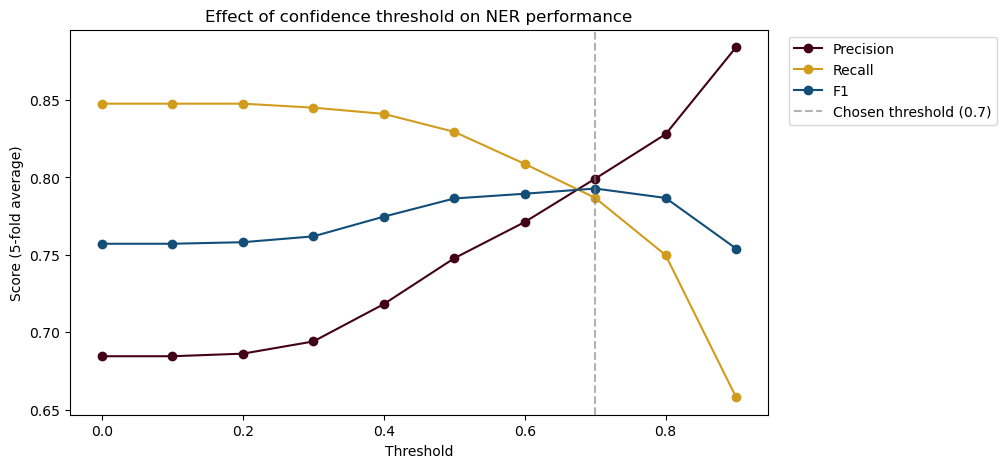

In [ ]:
def get_fold_logits(fold_num, checkpoints_dir, tokenizer, data_collator):
    trainer_reloaded = load_fold_trainer(fold_num, checkpoints_dir, tokenizer, data_collator)
    val_sents_fold = [s for s in sentences if s["fold"] == fold_num]
    ds_val_reloaded = build_dataset(val_sents_fold, tokenizer, label_to_id)
    raw_logits, labels, _ = trainer_reloaded.predict(ds_val_reloaded)
    return raw_logits, labels


def score_at_threshold(raw_logits, labels, id_to_label, threshold):
    probs = torch.nn.functional.softmax(torch.tensor(raw_logits), dim=-1).numpy()
    predictions = np.argmax(probs, axis=2)
    confidences = np.max(probs, axis=2)

    o_id = label_to_id["O"]
    predictions = np.where(confidences < threshold, o_id, predictions)

    true_labels = [[id_to_label[l] for l in label if l != -100] for label in labels]
    true_predictions = [
        [id_to_label[p] for p, l in zip(pred, label) if l != -100]
        for pred, label in zip(predictions, labels)
    ]
    return {
        "precision": precision_score(true_labels, true_predictions),
        "recall": recall_score(true_labels, true_predictions),
        "f1": f1_score(true_labels, true_predictions),
    }


fold_logits_cache = [get_fold_logits(f, CHECKPOINTS_DIR, tokenizer, data_collator) for f in range(N_FOLDS)]

THRESHOLD_VALUES = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
sweep_results = {t: [] for t in THRESHOLD_VALUES}

for raw_logits, labels in fold_logits_cache:
    for t in THRESHOLD_VALUES:
        sweep_results[t].append(score_at_threshold(raw_logits, labels, id_to_label, t))

sweep_avg = {
    t: {m: np.mean([r[m] for r in results]) for m in ["precision", "recall", "f1"]}
    for t, results in sweep_results.items()
}

sweep_path = os.path.join(EVAL_DIR, "threshold_sweep.csv")
with open(sweep_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["threshold", "precision", "recall", "f1"])
    for t in THRESHOLD_VALUES:
        writer.writerow([t, round(sweep_avg[t]["precision"], 3), round(sweep_avg[t]["recall"], 3), round(sweep_avg[t]["f1"], 3)])
print(f"Wrote threshold_sweep.csv")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(THRESHOLD_VALUES, [sweep_avg[t]["precision"] for t in THRESHOLD_VALUES], marker="o", label="Precision", color="#420217")
ax.plot(THRESHOLD_VALUES, [sweep_avg[t]["recall"] for t in THRESHOLD_VALUES], marker="o", label="Recall", color="#D19C1D")
ax.plot(THRESHOLD_VALUES, [sweep_avg[t]["f1"] for t in THRESHOLD_VALUES], marker="o", label="F1", color="#124E78")
ax.axvline(CONFIDENCE_THRESHOLD, color="gray", linestyle="--", alpha=0.6, label=f"Chosen threshold ({CONFIDENCE_THRESHOLD})")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score (5-fold average)")
ax.set_title("Effect of confidence threshold on NER performance")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))  # outside, to the right

chart_path = os.path.join(FIGURES_DIR, "threshold_sweep.png")
fig.savefig(chart_path, dpi=150, bbox_inches="tight")
print("Wrote threshold_sweep.png")
plt.show()

## Final Model Training

The definitive model is trained across the entire annotated dataset, keeping a 10% stratified slice for early stopping.

The final checkpoint and tokenizer are serialized to `checkpoints/final/saved_model`.

In [ ]:
mskf_final = MultilabelStratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)
final_train_idx, final_val_idx = next(mskf_final.split(X, Y))

final_train_sents = [sentences[i] for i in final_train_idx]
final_val_sents = [sentences[i] for i in final_val_idx]
print(f"Final model: {len(final_train_sents)} train sentences, "
      f"{len(final_val_sents)} monitoring-only validation sentences")

ds_train_final = build_dataset(final_train_sents, tokenizer, label_to_id)
ds_val_final = build_dataset(final_val_sents, tokenizer, label_to_id)

set_all_seeds(RANDOM_SEED)

final_model = AutoModelForTokenClassification.from_pretrained(
    BERT_MODEL_NAME,
    num_labels=len(label_list),
    id2label=id_to_label,
    label2id=label_to_id,
)

final_training_args = TrainingArguments(
    output_dir=os.path.join(CHECKPOINTS_DIR, "final"),
    num_train_epochs=6,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=1,
    logging_steps=10,
    report_to="none",
)

final_trainer = WeightedLossTrainer(
    model=final_model,
    args=final_training_args,
    train_dataset=ds_train_final,
    eval_dataset=ds_val_final,
    data_collator=data_collator,
    class_weights=class_weights_capped,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

final_trainer.train()

# Save for reuse
FINAL_MODEL_DIR = os.path.join(CHECKPOINTS_DIR, "final", "saved_model")
final_trainer.save_model(FINAL_MODEL_DIR)
tokenizer.save_pretrained(FINAL_MODEL_DIR)
print("Final model saved to checkpoints/final/saved_model")

Final model: 274 train sentences, 31 monitoring-only validation sentences


Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss
1,0.800100,0.550570
2,0.525300,0.346778
3,0.330600,0.303804
4,0.238200,0.297547
5,0.122800,0.298415
6,0.072100,0.295966


Final model saved to checkpoints/final/saved_model


---

# 2. Inference on the Full Corpus

## Identification of Unannotated Sentences

Sentence IDs from `final_annotation.csv` are cross-referenced against all parsed sentences in `sentence_scores.csv` to isolate the unannotated corpus subset.

In [23]:
def load_annotated_sentence_ids(path):
    with open(path, newline="", encoding="utf-8") as f:
        return {row["sentence_id"] for row in csv.DictReader(f)}


def load_unannotated_sentences(sentence_scores_path, annotated_ids):
    with open(sentence_scores_path, newline="", encoding="utf-8") as f:
        rows = list(csv.DictReader(f))
    return [r for r in rows if r["sentence_id"] not in annotated_ids]


annotated_ids = load_annotated_sentence_ids(FINAL_ANNOTATION_PATH)
unannotated = load_unannotated_sentences(SENTENCE_SCORES_PATH, annotated_ids)

print(f"Annotated (gold-standard) sentence IDs: {len(annotated_ids)}")
print(f"Unannotated sentences to run inference on: {len(unannotated)}")

Annotated (gold-standard) sentence IDs: 305
Unannotated sentences to run inference on: 575


## Inference function

`predict_with_threshold()` processes single sentences and applies the `CONFIDENCE_THRESHOLD` (0.7). Predictions below the threshold are mapped to the background `"O"` class, matching the post-processing pipeline established during model evaluation.

In [24]:
def predict_with_threshold(text, model, tokenizer, label_to_id, id_to_label, threshold=CONFIDENCE_THRESHOLD):
    device = next(model.parameters()).device
    encoding = tokenizer(text, return_offsets_mapping=True, truncation=True, return_tensors="pt")
    offsets = encoding["offset_mapping"][0].tolist()
    word_ids = encoding.word_ids(batch_index=0)
    model_inputs = {k: v.to(device) for k, v in encoding.items() if k != "offset_mapping"}

    model.eval()
    with torch.no_grad():
        logits = model(**model_inputs).logits[0]
    probs = torch.softmax(logits, dim=-1)
    confidences, pred_ids = torch.max(probs, dim=-1)

    o_id = label_to_id["O"]
    pred_ids = torch.where(confidences < threshold, torch.full_like(pred_ids, o_id), pred_ids)

    return decode_bio_to_spans(offsets, word_ids, pred_ids.tolist(), id_to_label)


# test
predict_with_threshold("The wind swept over the mountain.", final_model, tokenizer, label_to_id, id_to_label)

[{'start': 4, 'end': 8, 'label': 'WEATHER'},
 {'start': 24, 'end': 32, 'label': 'LANDSCAPE'}]

## Full-Corpus Inference Execution

Runs `predict_with_threshold()` over every sentence, returning one row per predicted entity.

In [25]:
def run_inference_on_corpus(unannotated_sentences, model, tokenizer, label_to_id, id_to_label):
    results = []
    for row in unannotated_sentences:
        sentence_id = row["sentence_id"]
        text = row["sentence_text"]
        spans = predict_with_threshold(text, model, tokenizer, label_to_id, id_to_label)

        if not spans:
            # no entities predicted - still record the sentence
            results.append({
                "sentence_id": sentence_id, "sentence_text": text,
                "target_span": "", "start_char": "", "end_char": "", "entity_type": "",
            })
        else:
            for s in spans:
                results.append({
                    "sentence_id": sentence_id, "sentence_text": text,
                    "target_span": text[s["start"]:s["end"]],
                    "start_char": s["start"], "end_char": s["end"],
                    "entity_type": s["label"],
                })
    return results


inferred = run_inference_on_corpus(unannotated, final_model, tokenizer, label_to_id, id_to_label)

n_sentences_with_entities = len({r["sentence_id"] for r in inferred if r["target_span"]})
n_total_entities = sum(1 for r in inferred if r["target_span"])
print(f"Ran inference on {len(unannotated)} sentences\n"
      f"  {n_sentences_with_entities} received at least one predicted entity\n"
      f"  {n_total_entities} entities predicted in total")

Ran inference on 575 sentences
  107 received at least one predicted entity
  150 entities predicted in total


## Entity Density Verification

The model predicts 150 entities across the 575 unnannotated sentences (0.26 entities/sentence), compared to 795 entities across 305 sentences (2.61 entities/sentence) in the gold-standard dataset.

To evaluate whether this lower density reflects model under-prediction or true content sparsity, entity detection rates are cross-referenced against the WordNet candidate counts (`n_candidates` bands) from `sentence_scores.csv`.

**Key Findings:**
*   **Corpus Sparsity:** No high-density sentences (`band_2` or `band_3plus`) remain in the unannotated pool.
*   **Lexicon Generalization:** Sentences in `band_0` (zero WordNet candidates) produced entity predictions 12.2% of the time, and `band_1` sentences (a single candidate) produced predictions 60.5% of the time. This demonstrates the model capacity to extract novel entity spans beyond static lexicon lookup, not just a marginal edge case.
*   **Density Alignment:** The average WordNet candidate count drops from 2.13 in the annotated set to 0.13 in the unannotated set. Relative to this baseline, entities are extracted at a higher proportional rate than the initial lexicon heuristic predicted.

In [26]:
scores_by_id = {}
with open(SENTENCE_SCORES_PATH, newline="", encoding="utf-8") as f:
    for row in csv.DictReader(f):
        scores_by_id[row["sentence_id"]] = row

entity_counts_by_id = {}
for r in inferred:
    if r["target_span"]:
        entity_counts_by_id[r["sentence_id"]] = entity_counts_by_id.get(r["sentence_id"], 0) + 1

from collections import defaultdict
band_totals = defaultdict(lambda: [0, 0])  # band -> [sentences, sentences_with_predictions]
for row in unannotated:
    sid = row["sentence_id"]
    band = scores_by_id[sid]["band"]
    band_totals[band][0] += 1
    if entity_counts_by_id.get(sid, 0) > 0:
        band_totals[band][1] += 1

print(f"{'band':12s} {'sentences':>10s} {'got predictions':>18s} {'%':>8s}")
for band in sorted(band_totals):
    total, with_pred = band_totals[band]
    print(f"{band:12s} {total:>10d} {with_pred:>18d} {100*with_pred/total:>7.1f}%")

# average annotated-vs-unannotated WordNet density
annotated_scores = [int(scores_by_id[sid]["n_candidates"]) for sid in annotated_ids if sid in scores_by_id]
unannotated_scores = [int(row["n_candidates"]) for row in unannotated]
print(f"\nAverage WordNet n_candidates - annotated set: {sum(annotated_scores)/len(annotated_scores):.2f}")
print(f"Average WordNet n_candidates - unannotated set: {sum(unannotated_scores)/len(unannotated_scores):.2f}")

band          sentences    got predictions        %
band_0              499                 61    12.2%
band_1               76                 46    60.5%

Average WordNet n_candidates - annotated set: 2.13
Average WordNet n_candidates - unannotated set: 0.13


## Exporting Results

Predictions are serialized to `inferred_entities.csv` -> same column structure as `final_annotation.csv`'s target columns

In [ ]:
fieldnames = ["sentence_id", "sentence_text", "target_span", "start_char", "end_char", "entity_type"]

with open(OUTPUT_PATH, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(inferred)

print(f"Wrote {len(inferred)} rows to inferred_entities.csv")
print(f"({n_sentences_with_entities} sentences with entities, "
      f"{len(unannotated) - n_sentences_with_entities} sentences with none)")

Wrote 618 rows to inferred_entities.csv
  (107 sentences with entities, 468 sentences with none)


## Entity Category Composition

Combine gold-standard (`sentences`) and model-predicted (`inferred`) entities into one count per category, across the entire corpus - showing the actual composition of non-human nature representation in these texts.

Total entity mentions across full corpus: 945
FLORA          86  (9.1%)
FAUNA          57  (6.0%)
WEATHER       394  (41.7%)
LANDSCAPE     367  (38.8%)
NATURE         41  (4.3%)

Wrote category_composition.csv
Wrote category_composition.png


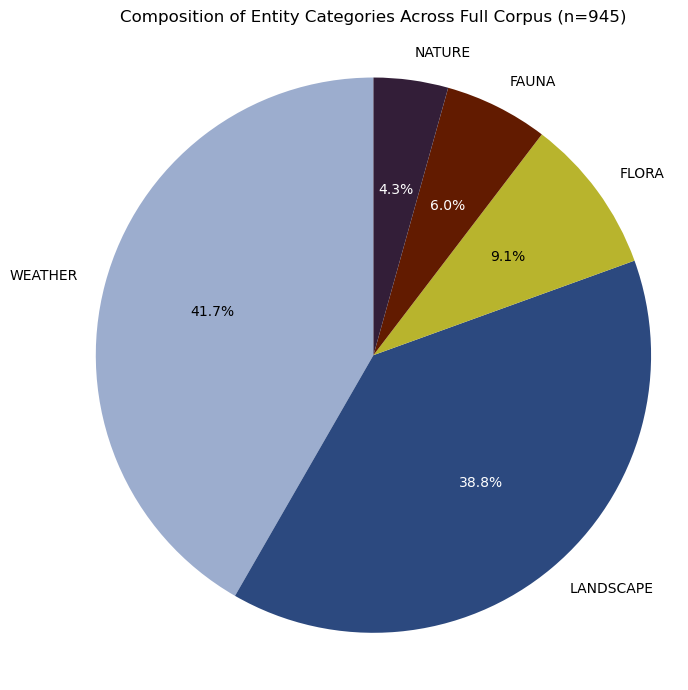

In [ ]:
def luminance(hex_color):
    hex_color = hex_color.lstrip("#")
    r, g, b = [int(hex_color[i:i+2], 16) / 255 for i in (0, 2, 4)]
    def lin(c):
        return c / 12.92 if c <= 0.03928 else ((c + 0.055) / 1.055) ** 2.4
    r, g, b = lin(r), lin(g), lin(b)
    return 0.2126 * r + 0.7152 * g + 0.0722 * b


CATEGORY_COLORS = {
    "WEATHER":   "#9CADCE",
    "LANDSCAPE": "#2C497F",
    "FLORA":     "#B8B42D",
    "FAUNA":     "#621B00",
    "NATURE":    "#331E38",
}

corpus_type_counts = Counter()

for s in sentences:
    for e in s["entities"]:
        corpus_type_counts[e["label"]] += 1

for r in inferred:
    if r["entity_type"]:
        corpus_type_counts[r["entity_type"]] += 1

total = sum(corpus_type_counts.values())
print(f"Total entity mentions across full corpus: {total}")
for cat in ENTITY_TYPES:
    count = corpus_type_counts[cat]
    print(f"{cat:12s} {count:4d}  ({100*count/total:.1f}%)")

composition_path = os.path.join(INFERRED_DIR, "category_composition.csv")
with open(composition_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["entity_type", "count", "percent"])
    for cat in ENTITY_TYPES:
        writer.writerow([cat, corpus_type_counts[cat], round(100 * corpus_type_counts[cat] / total, 1)])
print("\nWrote category_composition.csv")

# sort by count, descending -- labels/sizes/colors stay in sync throughout
sorted_cats = sorted(ENTITY_TYPES, key=lambda cat: -corpus_type_counts[cat])
labels = sorted_cats
sizes = [corpus_type_counts[cat] for cat in sorted_cats]
colors = [CATEGORY_COLORS[cat] for cat in sorted_cats]

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90, colors=colors)

for autotext, cat in zip(autotexts, sorted_cats):
    autotext.set_color("white" if luminance(CATEGORY_COLORS[cat]) < 0.4 else "black")

ax.set_title(f"Composition of Entity Categories Across Full Corpus (n={total})")
ax.axis("equal")
fig.tight_layout()

chart_path = os.path.join(FIGURES_DIR, "category_composition.png")
fig.savefig(chart_path, dpi=150, bbox_inches="tight")
print("Wrote category_composition.png")
plt.show()